# Ασαφή Σύνολα & Ασαφής Λογική
## Συναρτήσεις Συμμετοχής · Γλωσσικές Μεταβλητές · Ασαφείς Κανόνες

---

## 0. Εγκατάσταση βιβλιοθηκών
Εκτέλεσε το παρακάτω κελί μία φορά αν δεν έχεις ήδη εγκαταστήσει τις βιβλιοθήκες.

In [12]:
!pip install numpy matplotlib ipywidgets
# Αποσχολίασε αν χρειαστεί


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, FloatSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 1. Συναρτήσεις Συμμετοχής (Membership Functions)

Η συνάρτηση συμμετοχής `μ_A : X → [0,1]` εκφράζει τον **βαθμό** με τον οποίο ένα στοιχείο `x` ανήκει στο ασαφές σύνολο `A`:

| Τιμή | Ερμηνεία |
|------|----------|
| `μ(x) = 0` | Δεν ανήκει καθόλου |
| `0 < μ(x) < 1` | Μερική συμμετοχή |
| `μ(x) = 1` | Πλήρης συμμετοχή |

In [14]:
# ── Ορισμός συναρτήσεων συμμετοχής ──────────────────────────────────

def triangular(x, a, b, c):
    """Τριγωνική MF με κορυφή στο b."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    left  = (x > a) & (x <= b)
    right = (x > b) & (x < c)
    y[left]  = (x[left]  - a) / (b - a)
    y[right] = (c - x[right]) / (c - b)
    return y


def trapezoidal(x, a, b, c, d):
    """Τραπεζοειδής MF με πλατό [b, c]."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    y[(x >= b) & (x <= c)] = 1.0
    left  = (x > a) & (x < b)
    right = (x > c) & (x < d)
    y[left]  = (x[left]  - a) / (b - a)
    y[right] = (d - x[right]) / (d - c)
    return y


def gaussian(x, c, sigma):
    """Gaussian MF με κέντρο c και πλάτος sigma."""
    return np.exp(-0.5 * ((np.asarray(x, dtype=float) - c) / sigma) ** 2)


def sigmoid(x, k, c0):
    """Sigmoid MF με κλίση k και κέντρο c0."""
    return 1 / (1 + np.exp(-k * (np.asarray(x, dtype=float) - c0)))


print('Συναρτήσεις ορίστηκαν: triangular, trapezoidal, gaussian, sigmoid')

Συναρτήσεις ορίστηκαν: triangular, trapezoidal, gaussian, sigmoid


### 1.1 Σύγκριση και των 4 μορφών

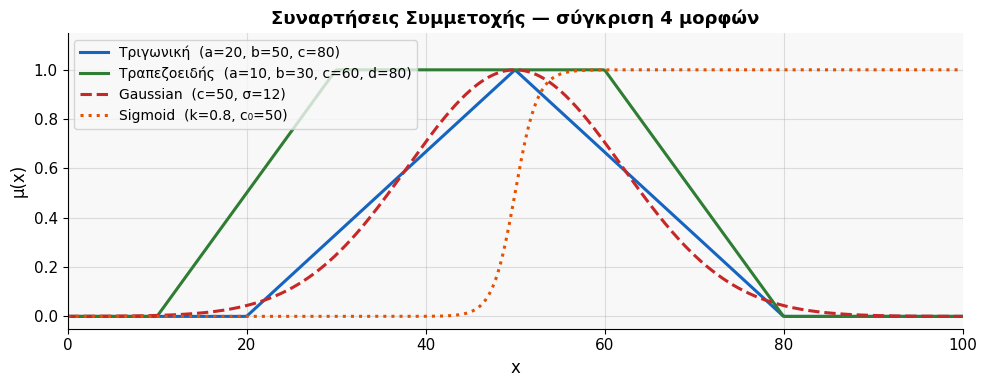

In [15]:
x = np.linspace(0, 100, 500)

configs = [
    ('Τριγωνική',    triangular(x, 20, 50, 80),  '#1565C0', '-',  'a=20, b=50, c=80'),
    ('Τραπεζοειδής', trapezoidal(x,10,30,60,80), '#2E7D32', '-',  'a=10, b=30, c=60, d=80'),
    ('Gaussian',     gaussian(x, 50, 12),         '#C62828', '--', 'c=50, σ=12'),
    ('Sigmoid',      sigmoid(x, 0.8, 50),         '#E65100', ':',  'k=0.8, c₀=50'),
]

fig, ax = plt.subplots(figsize=(10, 4))

for name, y, color, ls, params in configs:
    ax.plot(x, y, color=color, linestyle=ls, linewidth=2.2,
            label=f'{name}  ({params})')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('μ(x)', fontsize=12)
ax.set_title('Συναρτήσεις Συμμετοχής — σύγκριση 4 μορφών', fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.15)
ax.set_xlim(0, 100)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Διαδραστική εξερεύνηση συνάρτησης συμμετοχής

In [16]:
x = np.linspace(0, 100, 500)

def plot_mf(mf_type, a_b_c=50.0, spread=15.0, d=80.0):
    fig, ax = plt.subplots(figsize=(9, 3.5))

    if mf_type == 'Τριγωνική':
        a = max(0, a_b_c - spread)
        c = min(100, a_b_c + spread)
        y = triangular(x, a, a_b_c, c)
        title = f'Τριγωνική: a={a:.0f}, b={a_b_c:.0f}, c={c:.0f}'
        color = '#1565C0'
    elif mf_type == 'Τραπεζοειδής':
        a = max(0, a_b_c - spread - 10)
        b = max(0, a_b_c - spread)
        c = min(100, a_b_c + spread)
        dd = min(100, a_b_c + spread + 10)
        y = trapezoidal(x, a, b, c, dd)
        title = f'Τραπεζοειδής: a={a:.0f}, b={b:.0f}, c={c:.0f}, d={dd:.0f}'
        color = '#2E7D32'
    elif mf_type == 'Gaussian':
        y = gaussian(x, a_b_c, spread)
        title = f'Gaussian: c={a_b_c:.0f}, σ={spread:.1f}'
        color = '#C62828'
    else:
        k = spread / 10
        y = sigmoid(x, k, a_b_c)
        title = f'Sigmoid: k={k:.2f}, c₀={a_b_c:.0f}'
        color = '#E65100'

    ax.fill_between(x, y, alpha=0.15, color=color)
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlim(0, 100)
    ax.set_xlabel('x'); ax.set_ylabel('μ(x)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

interact(
    plot_mf,
    mf_type=Dropdown(options=['Τριγωνική','Τραπεζοειδής','Gaussian','Sigmoid'],
                     description='Τύπος MF:'),
    a_b_c=FloatSlider(value=50, min=5, max=95, step=1, description='Κέντρο b/c₀:'),
    spread=FloatSlider(value=15, min=2, max=40, step=1, description='Εύρος σ:'),
)

interactive(children=(Dropdown(description='Τύπος MF:', options=('Τριγωνική', 'Τραπεζοειδής', 'Gaussian', 'Sig…

<function __main__.plot_mf(mf_type, a_b_c=50.0, spread=15.0, d=80.0)>

---
## 2. Γλωσσικές Μεταβλητές (Linguistic Variables)

Μια γλωσσική μεταβλητή αποτελείται από:
- **Όνομα**: π.χ. «Θερμοκρασία»
- **Σύμπαν ορισμού**: π.χ. [0°C, 45°C]
- **Γλωσσικοί όροι**: {Δροσερή, Μέτρια, Ζεστή, Καυτή}
- **Συναρτήσεις συμμετοχής**: μία για κάθε όρο

In [17]:
# ── Ορισμός γλωσσικών μεταβλητών ─────────────────────────────────────

x_temp = np.linspace(0, 45, 500)
x_hum  = np.linspace(0, 100, 500)

temp_terms = {
    'Δροσερή': (trapezoidal(x_temp, 0,  0, 18, 26), '#1565C0'),
    'Μέτρια':  (triangular( x_temp, 20, 27, 34),    '#2E7D32'),
    'Ζεστή':   (triangular( x_temp, 28, 34, 40),    '#F57C00'),
    'Καυτή':   (trapezoidal(x_temp, 36, 41, 45, 45),'#C62828'),
}

hum_terms = {
    'Χαμηλή': (trapezoidal(x_hum,  0,  0, 30, 50), '#1565C0'),
    'Μέτρια': (triangular( x_hum, 35, 55, 75),     '#2E7D32'),
    'Υψηλή':  (trapezoidal(x_hum, 60, 80,100,100), '#C62828'),
}

print('Γλωσσικές μεταβλητές ορίστηκαν: Θερμοκρασία, Υγρασία')

Γλωσσικές μεταβλητές ορίστηκαν: Θερμοκρασία, Υγρασία


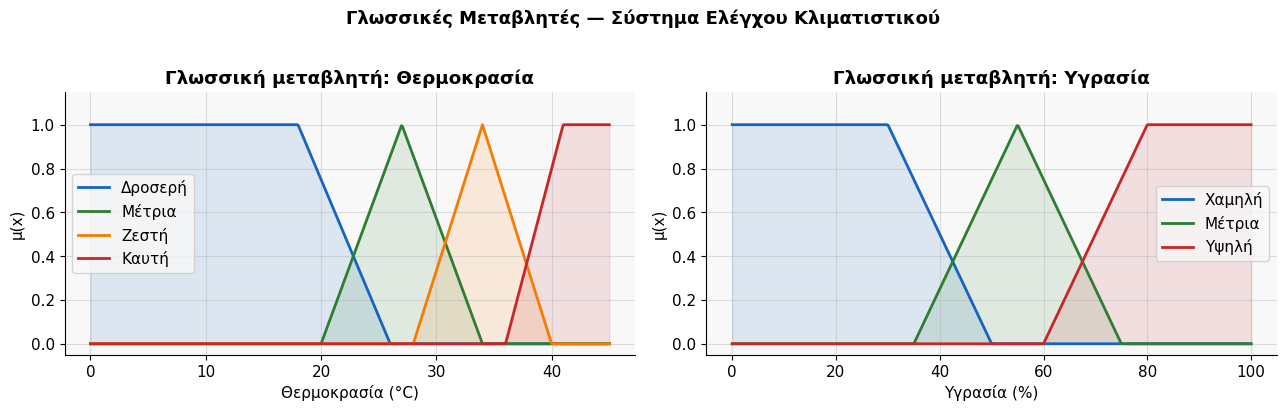

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Θερμοκρασία
ax = axes[0]
for term, (y, col) in temp_terms.items():
    ax.fill_between(x_temp, y, alpha=0.12, color=col)
    ax.plot(x_temp, y, color=col, linewidth=2, label=term)
ax.set_title('Γλωσσική μεταβλητή: Θερμοκρασία', fontweight='bold')
ax.set_xlabel('Θερμοκρασία (°C)'); ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.15); ax.legend()

# -- Υγρασία
ax = axes[1]
for term, (y, col) in hum_terms.items():
    ax.fill_between(x_hum, y, alpha=0.12, color=col)
    ax.plot(x_hum, y, color=col, linewidth=2, label=term)
ax.set_title('Γλωσσική μεταβλητή: Υγρασία', fontweight='bold')
ax.set_xlabel('Υγρασία (%)'); ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.15); ax.legend()

plt.suptitle('Γλωσσικές Μεταβλητές — Σύστημα Ελέγχου Κλιματιστικού',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('linguistic_variables.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 Διαδραστικό — βαθμός συμμετοχής για δοσμένη τιμή

In [29]:
def plot_fuzzification(temp=32.0, hum=65.0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, x_arr, terms, val, xlabel, title in [
        (axes[0], x_temp, temp_terms, temp, 'Θερμοκρασία (°C)', 'Fuzzification — Θερμοκρασία'),
        (axes[1], x_hum,  hum_terms,  hum,  'Υγρασία (%)',       'Fuzzification — Υγρασία'),
    ]:
        for term, (y, col) in terms.items():
            ax.fill_between(x_arr, y, alpha=0.12, color=col)
            ax.plot(x_arr, y, color=col, linewidth=2, label=term)

        ax.axvline(val, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label=f'x = {val}')

        for term, (y, col) in terms.items():
            idx = np.argmin(np.abs(x_arr - val))
            mu  = y[idx]
            if mu > 0.01:
                ax.plot(val, mu, 'o', color=col, markersize=8)
                ax.annotate(f'  μ={mu:.2f}', (val, mu), fontsize=9, color=col)

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(xlabel); ax.set_ylabel('μ(x)')
        ax.set_ylim(-0.05, 1.2); ax.legend(fontsize=9)

    plt.tight_layout(); plt.show()

interact(
    plot_fuzzification,
    temp=FloatSlider(value=32, min=0,  max=45,  step=0.5, description='Θερμ. (°C):'),
    hum= FloatSlider(value=65, min=0,  max=100, step=1,   description='Υγρασία (%):'),
)

interactive(children=(FloatSlider(value=32.0, description='Θερμ. (°C):', max=45.0, step=0.5), FloatSlider(valu…

<function __main__.plot_fuzzification(temp=32.0, hum=65.0)>

---
## 3. Ασαφείς Κανόνες (Fuzzy Rules) & Inference

Οι κανόνες έχουν μορφή **IF–THEN**:
```
ΑΝ θερμοκρασία = Ζεστή  ΚΑΙ  υγρασία = Υψηλή  ΤΟΤΕ  κλιματιστικό = Πλήρες
```

Η ενεργοποίηση κάθε κανόνα υπολογίζεται ως:
```
fire = min( μ_temp(x), μ_hum(x) )   ← Mamdani AND
```

Η τελική έξοδος προκύπτει με **Defuzzification** (σταθμισμένος μέσος).

In [30]:
# ── Ορισμός κανόνων ───────────────────────────────────────────────────

# Γλωσσικοί όροι εξόδου (ισχύς κλιματιστικού 0–100%)
output_terms = {
    'Ανενεργό': 0,
    'Χαμηλό':   25,
    'Μέτριο':   50,
    'Δυνατό':   75,
    'Πλήρες':   100,
}

rules = [
    ('Δροσερή', 'Χαμηλή', 'Ανενεργό'),
    ('Δροσερή', 'Υψηλή',  'Χαμηλό'),
    ('Μέτρια',  'Χαμηλή', 'Χαμηλό'),
    ('Μέτρια',  'Μέτρια', 'Μέτριο'),
    ('Μέτρια',  'Υψηλή',  'Δυνατό'),
    ('Ζεστή',   'Μέτρια', 'Δυνατό'),
    ('Ζεστή',   'Υψηλή',  'Πλήρες'),
    ('Καυτή',   'Χαμηλή', 'Δυνατό'),
    ('Καυτή',   'Υψηλή',  'Πλήρες'),
]


def get_mu_temp(term, val):
    """Βαθμός συμμετοχής για θερμοκρασία."""
    fns = {
        'Δροσερή': lambda v: trapezoidal(np.array([v]), 0,  0, 18, 26)[0],
        'Μέτρια':  lambda v: triangular( np.array([v]), 20, 27, 34)[0],
        'Ζεστή':   lambda v: triangular( np.array([v]), 28, 34, 40)[0],
        'Καυτή':   lambda v: trapezoidal(np.array([v]), 36, 41, 45, 45)[0],
    }
    return fns[term](val)


def get_mu_hum(term, val):
    """Βαθμός συμμετοχής για υγρασία."""
    fns = {
        'Χαμηλή': lambda v: trapezoidal(np.array([v]),  0,  0, 30, 50)[0],
        'Μέτρια': lambda v: triangular( np.array([v]), 35, 55, 75)[0],
        'Υψηλή':  lambda v: trapezoidal(np.array([v]), 60, 80,100,100)[0],
    }
    return fns[term](val)


def fuzzy_inference(temp_val, hum_val, verbose=True):
    """Εκτελεί Mamdani inference και επιστρέφει την αποασαφοποιημένη έξοδο."""
    firings = []
    for t_term, h_term, out_term in rules:
        mt   = get_mu_temp(t_term, temp_val)
        mh   = get_mu_hum(h_term, hum_val)
        fire = min(mt, mh)
        firings.append((t_term, h_term, out_term, mt, mh, fire))

    if verbose:
        print(f"\nΕίσοδοι: Θερμοκρασία = {temp_val}°C, Υγρασία = {hum_val}%")
        print("-" * 72)
        print(f"{'Κανόνας':<42} {'μ_temp':>6} {'μ_hum':>6} {'fire':>6}")
        print("-" * 72)
        for t,h,o,mt,mh,f in firings:
            active = '●' if f > 0.01 else ' '
            print(f"{active} ΑΝ {t:<9} ΚΑΙ {h:<8} ΤΟΤΕ {o:<10} {mt:>6.3f} {mh:>6.3f} {f:>6.3f}")
        print("-" * 72)

    # Defuzzification — σταθμισμένος μέσος
    num = sum(f * output_terms[o] for _,_,o,_,_,f in firings)
    den = sum(f for *_,f in firings)
    output = num / den if den > 0 else 0

    if verbose:
        lbl = next((k for k,v in output_terms.items() if abs(v-output)<13), '—')
        print(f"\nΈξοδος (defuzzified): {output:.1f}%  →  {lbl}")

    return output, firings


_ = fuzzy_inference(32, 65)


Είσοδοι: Θερμοκρασία = 32°C, Υγρασία = 65%
------------------------------------------------------------------------
Κανόνας                                    μ_temp  μ_hum   fire
------------------------------------------------------------------------
  ΑΝ Δροσερή   ΚΑΙ Χαμηλή   ΤΟΤΕ Ανενεργό    0.000  0.000  0.000
  ΑΝ Δροσερή   ΚΑΙ Υψηλή    ΤΟΤΕ Χαμηλό      0.000  0.250  0.000
  ΑΝ Μέτρια    ΚΑΙ Χαμηλή   ΤΟΤΕ Χαμηλό      0.286  0.000  0.000
● ΑΝ Μέτρια    ΚΑΙ Μέτρια   ΤΟΤΕ Μέτριο      0.286  0.500  0.286
● ΑΝ Μέτρια    ΚΑΙ Υψηλή    ΤΟΤΕ Δυνατό      0.286  0.250  0.250
● ΑΝ Ζεστή     ΚΑΙ Μέτρια   ΤΟΤΕ Δυνατό      0.667  0.500  0.500
● ΑΝ Ζεστή     ΚΑΙ Υψηλή    ΤΟΤΕ Πλήρες      0.667  0.250  0.250
  ΑΝ Καυτή     ΚΑΙ Χαμηλή   ΤΟΤΕ Δυνατό      0.000  0.000  0.000
  ΑΝ Καυτή     ΚΑΙ Υψηλή    ΤΟΤΕ Πλήρες      0.000  0.250  0.000
------------------------------------------------------------------------

Έξοδος (defuzzified): 74.3%  →  Δυνατό


### 3.1 Οπτικοποίηση κανόνων & αποτελέσματος

In [31]:
def plot_inference(temp_val=32.0, hum_val=65.0):
    output, firings = fuzzy_inference(temp_val, hum_val, verbose=False)

    active = [(t,h,o,f) for t,h,o,_,_,f in firings if f > 0.01]
    n = max(len(active), 1)

    fig = plt.figure(figsize=(14, 3 + n * 0.9))
    rule_colors = {'Ανενεργό':'#888', 'Χαμηλό':'#1565C0',
                   'Μέτριο':'#2E7D32', 'Δυνατό':'#F57C00', 'Πλήρες':'#C62828'}

    # -- bar plot ενεργών κανόνων
    ax_rules = fig.add_axes([0.05, 0.15, 0.55, 0.75])
    labels = [f'ΑΝ {t} ΚΑΙ {h}\nΤΟΤΕ {o}' for t,h,o,_ in active]
    values = [f for *_,f in active]
    colors = [rule_colors.get(o, '#555') for _,_,o,_ in active]
    bars = ax_rules.barh(range(len(labels)), values, color=colors, alpha=0.75, height=0.6)
    ax_rules.set_yticks(range(len(labels)))
    ax_rules.set_yticklabels(labels, fontsize=10)
    ax_rules.set_xlim(0, 1.1)
    ax_rules.set_xlabel('Βαθμός ενεργοποίησης (fire strength)')
    ax_rules.set_title(f'Ενεργοί κανόνες  |  T={temp_val}°C, H={hum_val}%', fontweight='bold')
    for bar, val in zip(bars, values):
        ax_rules.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                      f'{val:.3f}', va='center', fontsize=9)

    # -- gauge έξοδος
    ax_out = fig.add_axes([0.68, 0.15, 0.28, 0.75])
    col = rule_colors[max(output_terms, key=lambda k: -abs(output_terms[k]-output))]
    ax_out.barh([0], [output], color=col, alpha=0.8, height=0.5)
    ax_out.barh([0], [100], color='#eee', alpha=0.5, height=0.5)
    ax_out.set_xlim(0, 110)
    ax_out.set_yticks([])
    ax_out.set_xlabel('Ισχύς κλιματιστικού (%)')
    ax_out.set_title('Έξοδος (defuzzified)', fontweight='bold')
    ax_out.text(output/2, 0, f'{output:.1f}%', ha='center', va='center',
                fontsize=16, fontweight='bold', color='white')
    for k, v in output_terms.items():
        ax_out.axvline(v, color='gray', linewidth=0.5, linestyle=':')
        ax_out.text(v, -0.45, k, ha='center', fontsize=8, color='gray', rotation=30)

    plt.savefig('fuzzy_inference.png', dpi=150, bbox_inches='tight')
    plt.show()

interact(
    plot_inference,
    temp_val=FloatSlider(value=32, min=0,  max=45,  step=0.5, description='Θερμ. (°C):'),
    hum_val= FloatSlider(value=65, min=0,  max=100, step=1,   description='Υγρασία (%):'),
)

interactive(children=(FloatSlider(value=32.0, description='Θερμ. (°C):', max=45.0, step=0.5), FloatSlider(valu…

<function __main__.plot_inference(temp_val=32.0, hum_val=65.0)>

---
### 3.2 Χειροκίνητος υπολογισμός βήμα-βήμα (T = 34 °C, H = 72%)

Επαληθεύουμε **αριθμητικά** το αποτέλεσμα που δίνει ο κώδικας,
ακολουθώντας τα 6 βήματα της διαφάνειας.


In [32]:
T_val, H_val = 34, 72

# ── Βήμα 3α: Fuzzification ───────────────────────────────────────────
mu_T = {term: get_mu_temp(term, T_val) for term in ["Δροσερή","Μέτρια","Ζεστή","Καυτή"]}
mu_H = {term: get_mu_hum(term,  H_val) for term in ["Χαμηλή","Μέτρια","Υψηλή"]}

print("=" * 52)
print(f"Βήμα 3α — Fuzzification  (T={T_val}°C, H={H_val}%)")
print("=" * 52)
print("\nΘερμοκρασία:")
for t, v in mu_T.items(): print(f"  μ_{t:<9}({T_val}) = {v:.3f}")
print("\nΥγρασία:")
for h, v in mu_H.items(): print(f"  μ_{h:<9}({H_val}) = {v:.3f}")

# ── Βήμα 4: Rule Evaluation ──────────────────────────────────────────
print("\n" + "=" * 52)
print("Βήμα 4 — Rule Evaluation  (AND = min)")
print("=" * 52)
firings_manual = []
for t_term, h_term, out_term in rules:
    mt   = mu_T[t_term]
    mh   = mu_H[h_term]
    fire = min(mt, mh)
    firings_manual.append((t_term, h_term, out_term, mt, mh, fire))
    mark = "  ← ενεργός" if fire > 0 else ""
    print(f"  ΑΝ {t_term:<9} ΚΑΙ {h_term:<8} → fire = min({mt:.3f},{mh:.3f}) = {fire:.3f}{mark}")

# ── Βήμα 5: Aggregation ──────────────────────────────────────────────
print("\n" + "=" * 52)
print("Βήμα 5 — Aggregation  (max ανά κατηγορία εξόδου)")
print("=" * 52)
agg_manual = {term: 0.0 for term in output_terms}
for t, h, out, mt, mh, fire in firings_manual:
    agg_manual[out] = max(agg_manual[out], fire)
for term, val in agg_manual.items():
    print(f"  μ_agg({term:<9}) = {val:.3f}")

# ── Βήμα 6: Defuzzification (Centroid/Singleton) ─────────────────────
print("\n" + "=" * 52)
print("Βήμα 6 — Defuzzification  (Centroid/Singleton)")
print("=" * 52)
num = sum(agg_manual[t] * v for t, v in output_terms.items())
den = sum(agg_manual.values())
P_star = num / den if den > 0 else 0
active = [(t, v) for t, v in output_terms.items() if agg_manual[t] > 0]
formula = " + ".join(f"{agg_manual[t]:.3f}×{v}" for t, v in active)
denom   = " + ".join(f"{agg_manual[t]:.3f}" for t, v in active)
print(f"\n  P* = ({formula}) / ({denom})")
print(f"     = {num:.3f} / {den:.3f} = {P_star:.1f}%")
print(f"\n  → Ισχύς κλιματιστικού: {P_star:.1f}%")


Βήμα 3α — Fuzzification  (T=34°C, H=72%)

Θερμοκρασία:
  μ_Δροσερή  (34) = 0.000
  μ_Μέτρια   (34) = 0.000
  μ_Ζεστή    (34) = 1.000
  μ_Καυτή    (34) = 0.000

Υγρασία:
  μ_Χαμηλή   (72) = 0.000
  μ_Μέτρια   (72) = 0.150
  μ_Υψηλή    (72) = 0.600

Βήμα 4 — Rule Evaluation  (AND = min)
  ΑΝ Δροσερή   ΚΑΙ Χαμηλή   → fire = min(0.000,0.000) = 0.000
  ΑΝ Δροσερή   ΚΑΙ Υψηλή    → fire = min(0.000,0.600) = 0.000
  ΑΝ Μέτρια    ΚΑΙ Χαμηλή   → fire = min(0.000,0.000) = 0.000
  ΑΝ Μέτρια    ΚΑΙ Μέτρια   → fire = min(0.000,0.150) = 0.000
  ΑΝ Μέτρια    ΚΑΙ Υψηλή    → fire = min(0.000,0.600) = 0.000
  ΑΝ Ζεστή     ΚΑΙ Μέτρια   → fire = min(1.000,0.150) = 0.150  ← ενεργός
  ΑΝ Ζεστή     ΚΑΙ Υψηλή    → fire = min(1.000,0.600) = 0.600  ← ενεργός
  ΑΝ Καυτή     ΚΑΙ Χαμηλή   → fire = min(0.000,0.000) = 0.000
  ΑΝ Καυτή     ΚΑΙ Υψηλή    → fire = min(0.000,0.600) = 0.000

Βήμα 5 — Aggregation  (max ανά κατηγορία εξόδου)
  μ_agg(Ανενεργό ) = 0.000
  μ_agg(Χαμηλό   ) = 0.000
  μ_agg(Μέτριο   ) = 0.000
  μ

---
### 3.3 Σύγκριση Defuzzification: Singleton vs Mamdani

Το σύστημά μας χρησιμοποιεί **Singleton** (Sugeno) έξοδο — κάθε γλωσσικός
όρος αντιστοιχεί σε έναν σταθερό αριθμό (0, 25, 50, 75, 100%). Στο **Mamdani**
οι έξοδοι έχουν πραγματικά σχήματα (MFs) και το centroid υπολογίζεται ως
κέντρο βάρους ολόκληρης της αθροισμένης ασαφούς περιοχής.


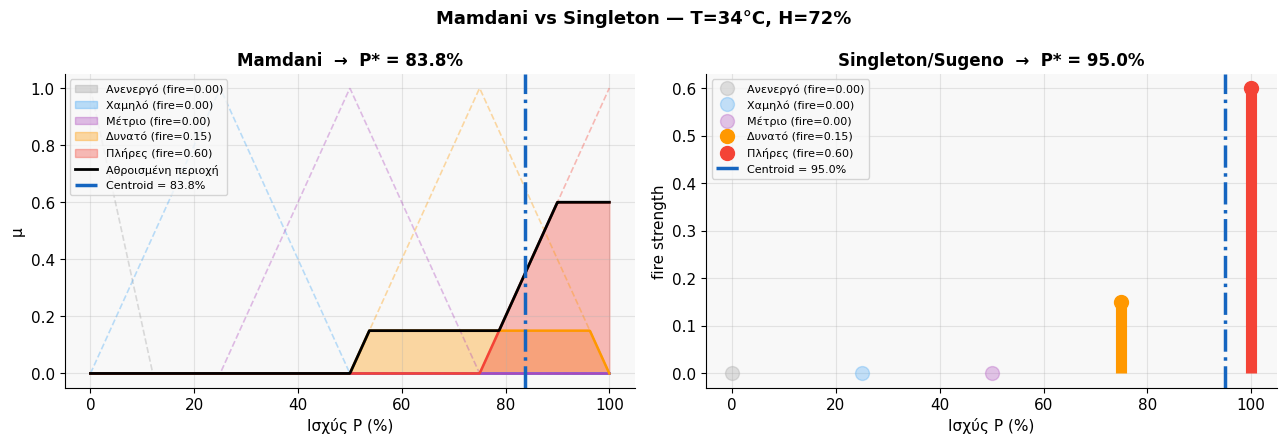


Mamdani  : 83.8%  (centroid αθροισμένης περιοχής)
Singleton: 95.0%  (σταθμισμένος μέσος singletons)
Διαφορά  : 11.2 ποσοστιαίες μονάδες


In [33]:
x_out = np.linspace(0, 100, 1000)

# Ορισμός MFs εξόδου (Mamdani — τρίγωνα/τραπέζια κεντραρισμένα στα singletons)
output_mfs_mamdani = {
    "Ανενεργό": trapezoidal(x_out,  0,  0,  0, 12),
    "Χαμηλό":   triangular( x_out,  0, 25, 50),
    "Μέτριο":   triangular( x_out, 25, 50, 75),
    "Δυνατό":   triangular( x_out, 50, 75, 100),
    "Πλήρες":   trapezoidal(x_out, 75, 100, 100, 100),
}

T_val, H_val = 34, 72
_, firings = fuzzy_inference(T_val, H_val, verbose=False)

# Aggregation για το παράδειγμα
agg = {term: 0.0 for term in output_terms}
for t, h, out, mt, mh, fire in firings:
    agg[out] = max(agg[out], fire)

# Mamdani: κλιπ κάθε MF στο fire, ένωση (max)
mu_agg = np.zeros_like(x_out)
for term, mf in output_mfs_mamdani.items():
    mu_agg = np.maximum(mu_agg, np.minimum(mf, agg[term]))

centroid_mamdani   = np.trapezoid(x_out * mu_agg, x_out) / np.trapezoid(mu_agg, x_out)
centroid_singleton = sum(agg[t] * v for t, v in output_terms.items()) / sum(agg.values())

colors = {"Ανενεργό":"#9E9E9E","Χαμηλό":"#42A5F5","Μέτριο":"#AB47BC",
          "Δυνατό":"#FF9800","Πλήρες":"#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Mamdani
ax = axes[0]
for term, mf in output_mfs_mamdani.items():
    clipped = np.minimum(mf, agg[term])
    ax.plot(x_out, mf, "--", color=colors[term], lw=1.2, alpha=0.35)
    ax.fill_between(x_out, clipped, alpha=0.35, color=colors[term],
                    label=f"{term} (fire={agg[term]:.2f})")
    ax.plot(x_out, clipped, "-", color=colors[term], lw=1.8)
ax.plot(x_out, mu_agg, "k-", lw=2, label="Αθροισμένη περιοχή")
ax.axvline(centroid_mamdani, color="#1565C0", lw=2.5, ls="-.",
           label=f"Centroid = {centroid_mamdani:.1f}%")
ax.set_title(f"Mamdani  →  P* = {centroid_mamdani:.1f}%", fontsize=12, fontweight="bold")
ax.set_xlabel("Ισχύς P (%)"); ax.set_ylabel("μ")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)

# Singleton
ax = axes[1]
for term, val in output_terms.items():
    col   = colors[term]
    alpha = 1.0 if agg[term] > 0 else 0.3
    ax.vlines(val, 0, agg[term], color=col, lw=8, alpha=alpha)
    ax.plot(val, agg[term], "o", color=col, ms=10, alpha=alpha,
            label=f"{term} (fire={agg[term]:.2f})")
ax.axvline(centroid_singleton, color="#1565C0", lw=2.5, ls="-.",
           label=f"Centroid = {centroid_singleton:.1f}%")
ax.set_title(f"Singleton/Sugeno  →  P* = {centroid_singleton:.1f}%",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Ισχύς P (%)"); ax.set_ylabel("fire strength")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)

fig.suptitle(f"Mamdani vs Singleton — T={T_val}°C, H={H_val}%",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"\nMamdani  : {centroid_mamdani:.1f}%  (centroid αθροισμένης περιοχής)")
print(f"Singleton: {centroid_singleton:.1f}%  (σταθμισμένος μέσος singletons)")
print(f"Διαφορά  : {abs(centroid_mamdani - centroid_singleton):.1f} ποσοστιαίες μονάδες")


---
## 4. Επιφάνεια Απόκρισης (Control Surface)

Η επιφάνεια απόκρισης δείχνει την έξοδο του συστήματος για **όλους** τους συνδυασμούς εισόδων.

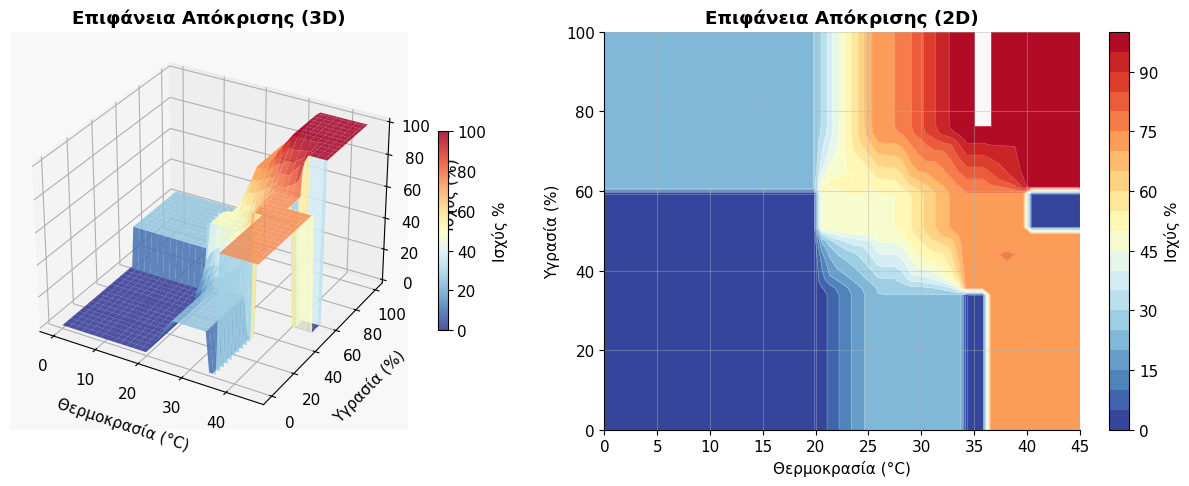

Αρχεία PNG αποθηκεύτηκαν στον τρέχοντα φάκελο.


In [34]:
temps = np.linspace(0, 45, 60)
hums  = np.linspace(0, 100, 60)
T, H  = np.meshgrid(temps, hums)
Z     = np.zeros_like(T)

for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        Z[i, j], _ = fuzzy_inference(T[i,j], H[i,j], verbose=False)

fig = plt.figure(figsize=(13, 5))

# 3D
ax3d = fig.add_subplot(121, projection='3d')
surf = ax3d.plot_surface(T, H, Z, cmap='RdYlBu_r', alpha=0.85, linewidth=0)
ax3d.set_xlabel('Θερμοκρασία (°C)', labelpad=8)
ax3d.set_ylabel('Υγρασία (%)', labelpad=8)
ax3d.set_zlabel('Ισχύς (%)', labelpad=8)
ax3d.set_title('Επιφάνεια Απόκρισης (3D)', fontweight='bold')
fig.colorbar(surf, ax=ax3d, shrink=0.5, label='Ισχύς %')

# 2D contour
ax2d = fig.add_subplot(122)
cp = ax2d.contourf(T, H, Z, levels=20, cmap='RdYlBu_r')
ax2d.contour(T, H, Z, levels=20, colors='white', linewidths=0.4, alpha=0.4)
fig.colorbar(cp, ax=ax2d, label='Ισχύς %')
ax2d.set_xlabel('Θερμοκρασία (°C)')
ax2d.set_ylabel('Υγρασία (%)')
ax2d.set_title('Επιφάνεια Απόκρισης (2D)', fontweight='bold')

plt.tight_layout()
plt.savefig('control_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αρχεία PNG αποθηκεύτηκαν στον τρέχοντα φάκελο.')

---
## 5. Σύνοψη

| Έννοια | Περιγραφή |
|--------|-----------|
| **Συνάρτηση συμμετοχής** | Μετρά τον βαθμό ανήκειν στο [0,1] |
| **Γλωσσική μεταβλητή** | Σύνολο ασαφών όρων (π.χ. Κρύα, Ζεστή) |
| **Ασαφής κανόνας** | IF–THEN σε φυσική γλώσσα |
| **Fuzzification** | Κριτή τιμή → βαθμοί συμμετοχής |
| **Inference** | Εφαρμογή κανόνων (Mamdani AND = min) |
| **Defuzzification** | Βαθμοί συμμετοχής → κριτή τιμή εξόδου |

### Επόμενα βήματα
- Δοκίμασε διαφορετικές μορφές MF (gaussian αντί τριγωνικής)
- Πρόσθεσε μια 3η είσοδο (π.χ. ώρα ημέρας)
- Εξερεύνησε το `scikit-fuzzy` για έτοιμα FIS

---
## 6. Ασαφής Λογική σε ΣΥΑ: Αξιολόγηση Πιστωτικού Ρίσκου

Η ασαφής λογική εφαρμόζεται ευρέως σε **Συστήματα Υποστήριξης Αποφάσεων**.
Παράδειγμα: αξιολόγηση αίτησης δανείου με δύο εισόδους:

| Μεταβλητή | Εύρος | Γλωσσικοί Όροι |
|-----------|-------|----------------|
| **Εισόδημα** | 0–5.000 €/μήνα | Χαμηλό · Μέτριο · Υψηλό |
| **Πιστοληπτική Βαθμολογία** | 300–850 | Χαμηλή · Μέτρια · Υψηλή |
| **Ρίσκο Δανείου** (έξοδος) | 0–100% | Χαμηλό · Μέτριο · Υψηλό |

**Παράδειγμα από τη διαφάνεια:** εισόδημα 1.400 €, βαθμολογία 550 —
μ(Εισόδημα=Μέτριο) ≈ 0.40, μ(Βαθμολογία=Χαμηλή) ≈ 0.70
→ AND = min(0.40, 0.70) = **0.40** · OR = max = **0.70** · NOT Χαμηλή = 1−0.70 = **0.30**


In [25]:
# ── Γλωσσικές μεταβλητές εισόδου/εξόδου ────────────────────────────────
x_inc   = np.linspace(0, 5000, 500)
x_score = np.linspace(300, 850, 500)

inc_terms = {
    "Χαμηλό":  trapezoidal(x_inc,    0,    0,  800, 1800),
    "Μέτριο":  triangular( x_inc, 1000, 2000, 3500),
    "Υψηλό":   trapezoidal(x_inc, 2800, 4000, 5000, 5000),
}
score_terms = {
    "Χαμηλή":  trapezoidal(x_score, 300, 300, 450, 580),
    "Μέτρια":  triangular( x_score, 480, 620, 720),
    "Υψηλή":   trapezoidal(x_score, 660, 750, 850, 850),
}
risk_out = {"Χαμηλό": 15, "Μέτριο": 50, "Υψηλό": 85}

credit_rules = [
    ("Χαμηλό","Χαμηλή","Υψηλό"), ("Χαμηλό","Μέτρια","Υψηλό"), ("Χαμηλό","Υψηλή","Μέτριο"),
    ("Μέτριο","Χαμηλή","Υψηλό"), ("Μέτριο","Μέτρια","Μέτριο"), ("Μέτριο","Υψηλή","Χαμηλό"),
    ("Υψηλό", "Χαμηλή","Μέτριο"),("Υψηλό", "Μέτρια","Χαμηλό"), ("Υψηλό", "Υψηλή","Χαμηλό"),
]

def mu_lookup(terms_dict, x_arr, term, val):
    return terms_dict[term][np.argmin(np.abs(x_arr - val))]

def credit_inference(income, score, verbose=True):
    firings = []
    for i_t, s_t, out_t in credit_rules:
        mi   = mu_lookup(inc_terms,   x_inc,   i_t, income)
        ms   = mu_lookup(score_terms, x_score, s_t, score)
        fire = min(mi, ms)
        firings.append((i_t, s_t, out_t, mi, ms, fire))

    agg = {t: 0.0 for t in risk_out}
    for i, s, out, mi, ms, fire in firings:
        agg[out] = max(agg[out], fire)

    den  = sum(agg.values())
    risk = sum(agg[t] * v for t, v in risk_out.items()) / den if den > 0 else 50

    if verbose:
        print(f"Είσοδοι: Εισόδημα={income} €/μήνα  |  Βαθμολογία={score}")
        print("-" * 65)
        for i, s, out, mi, ms, fire in firings:
            mark = "  ●" if fire > 0 else ""
            print(f"  ΑΝ {i:<8} ΚΑΙ {s:<8} → {out:<8}  mi={mi:.3f}  ms={ms:.3f}  fire={fire:.3f}{mark}")
        print("-" * 65)
        print("  Aggregation: " + "   ".join(f"{t}={v:.3f}" for t, v in agg.items()))
        label = "ΥΨΗΛΟ" if risk > 65 else ("ΜΕΤΡΙΟ" if risk > 35 else "ΧΑΜΗΛΟ")
        print(f"\n  Ρίσκο = {risk:.1f}%  →  [{label} ΡΙΣΚΟ]")
    return risk

credit_inference(1400, 550)


Είσοδοι: Εισόδημα=1400 €/μήνα  |  Βαθμολογία=550
-----------------------------------------------------------------
  ΑΝ Χαμηλό   ΚΑΙ Χαμηλή   → Υψηλό     mi=0.397  ms=0.229  fire=0.229  ●
  ΑΝ Χαμηλό   ΚΑΙ Μέτρια   → Υψηλό     mi=0.397  ms=0.501  fire=0.397  ●
  ΑΝ Χαμηλό   ΚΑΙ Υψηλή    → Μέτριο    mi=0.397  ms=0.000  fire=0.000
  ΑΝ Μέτριο   ΚΑΙ Χαμηλή   → Υψηλό     mi=0.403  ms=0.229  fire=0.229  ●
  ΑΝ Μέτριο   ΚΑΙ Μέτρια   → Μέτριο    mi=0.403  ms=0.501  fire=0.403  ●
  ΑΝ Μέτριο   ΚΑΙ Υψηλή    → Χαμηλό    mi=0.403  ms=0.000  fire=0.000
  ΑΝ Υψηλό    ΚΑΙ Χαμηλή   → Μέτριο    mi=0.000  ms=0.229  fire=0.000
  ΑΝ Υψηλό    ΚΑΙ Μέτρια   → Χαμηλό    mi=0.000  ms=0.501  fire=0.000
  ΑΝ Υψηλό    ΚΑΙ Υψηλή    → Χαμηλό    mi=0.000  ms=0.000  fire=0.000
-----------------------------------------------------------------
  Aggregation: Χαμηλό=0.000   Μέτριο=0.403   Υψηλό=0.397

  Ρίσκο = 67.4%  →  [ΥΨΗΛΟ ΡΙΣΚΟ]


np.float64(67.37725450901803)

In [26]:
from ipywidgets import interact, IntSlider

def plot_credit(income=1400, score=550):
    risk = credit_inference(income, score, verbose=False)
    label = "ΥΨΗΛΟ" if risk > 65 else ("ΜΕΤΡΙΟ" if risk > 35 else "ΧΑΜΗΛΟ")
    lcolor = "#F44336" if label=="ΥΨΗΛΟ" else ("#FF9800" if label=="ΜΕΤΡΙΟ" else "#388E3C")

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    c_inc   = ["#42A5F5","#AB47BC","#4CAF50"]
    c_score = ["#F44336","#FF9800","#1565C0"]

    # Εισόδημα
    ax = axes[0]
    for (term, mf), col in zip(inc_terms.items(), c_inc):
        ax.plot(x_inc, mf, lw=2, color=col, label=term)
        mu_v = mu_lookup(inc_terms, x_inc, term, income)
        ax.plot(income, mu_v, "o", color=col, ms=9)
    ax.axvline(income, color="red", lw=1.8, ls="--", label=f"{income} €")
    ax.set_xlabel("Εισόδημα (€/μήνα)"); ax.set_ylabel("μ")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title("Εισόδημα")

    # Βαθμολογία
    ax = axes[1]
    for (term, mf), col in zip(score_terms.items(), c_score):
        ax.plot(x_score, mf, lw=2, color=col, label=term)
        mu_v = mu_lookup(score_terms, x_score, term, score)
        ax.plot(score, mu_v, "o", color=col, ms=9)
    ax.axvline(score, color="red", lw=1.8, ls="--", label=f"Score={score}")
    ax.set_xlabel("Πιστοληπτική Βαθμολογία"); ax.set_ylabel("μ")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title("Πιστοληπτική Βαθμολογία")

    # Έξοδος
    agg = {t: 0.0 for t in risk_out}
    for i_t, s_t, out_t in credit_rules:
        mi = mu_lookup(inc_terms, x_inc, i_t, income)
        ms = mu_lookup(score_terms, x_score, s_t, score)
        agg[out_t] = max(agg[out_t], min(mi, ms))
    ax = axes[2]
    bar_colors = {"Χαμηλό":"#4CAF50","Μέτριο":"#FF9800","Υψηλό":"#F44336"}
    for term, val in risk_out.items():
        col   = bar_colors[term]
        alpha = 1.0 if agg[term] > 0 else 0.25
        ax.vlines(val, 0, agg[term], color=col, lw=10, alpha=alpha)
        ax.plot(val, agg[term], "o", color=col, ms=12, alpha=alpha,
                label=f"{term} ({agg[term]:.2f})")
    ax.axvline(risk, color="#1565C0", lw=2.5, ls="-.", label=f"Ρίσκο={risk:.1f}%")
    ax.set_title(f"Ρίσκο: {risk:.1f}%  [{label}]",
                 fontweight="bold", color=lcolor)
    ax.set_xlabel("Ρίσκο Δανείου (%)"); ax.set_ylabel("fire strength")
    ax.set_xlim(-5, 105); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

interact(plot_credit,
    income=IntSlider(min=0,   max=5000, step=100, value=1400,
                     description="Εισόδημα (€)", style={"description_width":"120px"}),
    score =IntSlider(min=300, max=850,  step=10,  value=550,
                     description="Βαθμολογία",   style={"description_width":"120px"}),
);


interactive(children=(IntSlider(value=1400, description='Εισόδημα (€)', max=5000, step=100, style=SliderStyle(…

---
## 7. Δίκτυα Bayes: Το Πρόβλημα του Συναγερμού (Judea Pearl)

Κλασικό παράδειγμα Βαϋεσιανού Δικτύου που δείχνει δύο βασικά φαινόμενα:
**διαγνωστικό συμπερασμό** και **explaining away**.

**Δομή δικτύου (DAG):**
```
  B (Διάρρηξη)    E (Σεισμός)
       ↘               ↙
         A (Συναγερμός)
```

**CPT — P(A=T | B, E):**

| B | E | P(A=T) | Ερμηνεία |
|---|---|--------|----------|
| T | T | 0.95 | Διάρρηξη + Σεισμός → σχεδόν σίγουρο |
| T | F | 0.94 | Μόνο διάρρηξη → σχεδόν σίγουρο |
| F | T | 0.29 | Μόνο σεισμός → αρκετά πιθανό |
| F | F | 0.001 | Τίποτα → σπάνιο βραχυκύκλωμα |

**Ερωτήματα:**
1. Ο γείτονας μας λέει **"Χτυπάει ο συναγερμός!"** — τι πιθανότητα Διάρρηξης;
2. Ακούμε επίσης **"Έγινε Σεισμός!"** — αλλάζει η πιθανότητα Διάρρηξης;


In [27]:
# ── CPT και priors ──────────────────────────────────────────────────────
P_B   = 0.001   # prior P(Διάρρηξη)
P_E   = 0.002   # prior P(Σεισμός)

# P(A=T | B, E)
P_A_given = {
    (True,  True):  0.950,
    (True,  False): 0.940,
    (False, True):  0.290,
    (False, False): 0.001,
}

# ── Βήμα 1: P(A=T) — ολική πιθανότητα ──────────────────────────────────
combos = [(True,True),(True,False),(False,True),(False,False)]
def P_BEcombo(b, e):
    return (P_B if b else 1-P_B) * (P_E if e else 1-P_E)

P_A_true = sum(P_A_given[(b,e)] * P_BEcombo(b,e) for b,e in combos)

print("=" * 58)
print("Βήμα 1 — Ολική πιθανότητα P(A=T)")
print("=" * 58)
for b, e in combos:
    contrib = P_A_given[(b,e)] * P_BEcombo(b,e)
    print(f"  P(A|B={str(b)[0]},E={str(e)[0]}) · P(B,E) = "
          f"{P_A_given[(b,e)]:.3f} × {P_BEcombo(b,e):.6f} = {contrib:.6f}")
print(f"  ─────────────────────────────────────────────────")
print(f"  P(A=T) = {P_A_true:.6f}  ({P_A_true*100:.4f}%)")

# ── Βήμα 2: P(B=T | A=T) — διαγνωστικός συμπερασμός ────────────────────
P_A_given_B  = sum(P_A_given[(True, e)] * (P_E if e else 1-P_E) for e in [True,False])
P_B_given_A  = P_A_given_B * P_B / P_A_true

print("\n" + "=" * 58)
print("Βήμα 2 — Διαγνωστικός συμπερασμός: P(B=T | A=T)")
print("=" * 58)
print(f"  P(A=T | B=T) = {P_A_given_B:.4f}")
print(f"  P(B=T | A=T) = P(A|B) · P(B) / P(A)")
print(f"               = {P_A_given_B:.4f} × {P_B} / {P_A_true:.6f}")
print(f"               = {P_B_given_A:.4f}  ({P_B_given_A*100:.1f}%)")
print(f"  Prior P(B=T) = {P_B} ({P_B*100:.1f}%)")
print(f"  ► Ο συναγερμός εκτοξεύει την πιθανότητα Διάρρηξης "
      f"από {P_B*100:.1f}% → {P_B_given_A*100:.1f}%!")

# ── Βήμα 3: Explaining Away — P(B=T | A=T, E=T) ─────────────────────────
numer = P_A_given[(True,True)]  * P_B
denom = P_A_given[(True,True)]  * P_B + P_A_given[(False,True)] * (1-P_B)
P_B_given_AE = numer / denom

print("\n" + "=" * 58)
print("Βήμα 3 — Explaining Away: P(B=T | A=T, E=T)")
print("=" * 58)
print(f"  P(B=T|A=T,E=T) = P(A|B=T,E=T)·P(B) / ")
print(f"    [P(A|B=T,E=T)·P(B) + P(A|B=F,E=T)·P(B=F)]")
print(f"  = {P_A_given[(True,True)]}·{P_B} / "
      f"({P_A_given[(True,True)]}·{P_B} + {P_A_given[(False,True)]}·{1-P_B})")
print(f"  = {numer:.5f} / {denom:.5f}")
print(f"  = {P_B_given_AE:.5f}  ({P_B_given_AE*100:.2f}%)")
print(f"  ► Ο σεισμός «εξηγεί» τον συναγερμό: Διάρρηξη "
      f"{P_B_given_A*100:.1f}% → {P_B_given_AE*100:.2f}%!")


Βήμα 1 — Ολική πιθανότητα P(A=T)
  P(A|B=T,E=T) · P(B,E) = 0.950 × 0.000002 = 0.000002
  P(A|B=T,E=F) · P(B,E) = 0.940 × 0.000998 = 0.000938
  P(A|B=F,E=T) · P(B,E) = 0.290 × 0.001998 = 0.000579
  P(A|B=F,E=F) · P(B,E) = 0.001 × 0.997002 = 0.000997
  ─────────────────────────────────────────────────
  P(A=T) = 0.002516  (0.2516%)

Βήμα 2 — Διαγνωστικός συμπερασμός: P(B=T | A=T)
  P(A=T | B=T) = 0.9400
  P(B=T | A=T) = P(A|B) · P(B) / P(A)
               = 0.9400 × 0.001 / 0.002516
               = 0.3736  (37.4%)
  Prior P(B=T) = 0.001 (0.1%)
  ► Ο συναγερμός εκτοξεύει την πιθανότητα Διάρρηξης από 0.1% → 37.4%!

Βήμα 3 — Explaining Away: P(B=T | A=T, E=T)
  P(B=T|A=T,E=T) = P(A|B=T,E=T)·P(B) / 
    [P(A|B=T,E=T)·P(B) + P(A|B=F,E=T)·P(B=F)]
  = 0.95·0.001 / (0.95·0.001 + 0.29·0.999)
  = 0.00095 / 0.29066
  = 0.00327  (0.33%)
  ► Ο σεισμός «εξηγεί» τον συναγερμό: Διάρρηξη 37.4% → 0.33%!


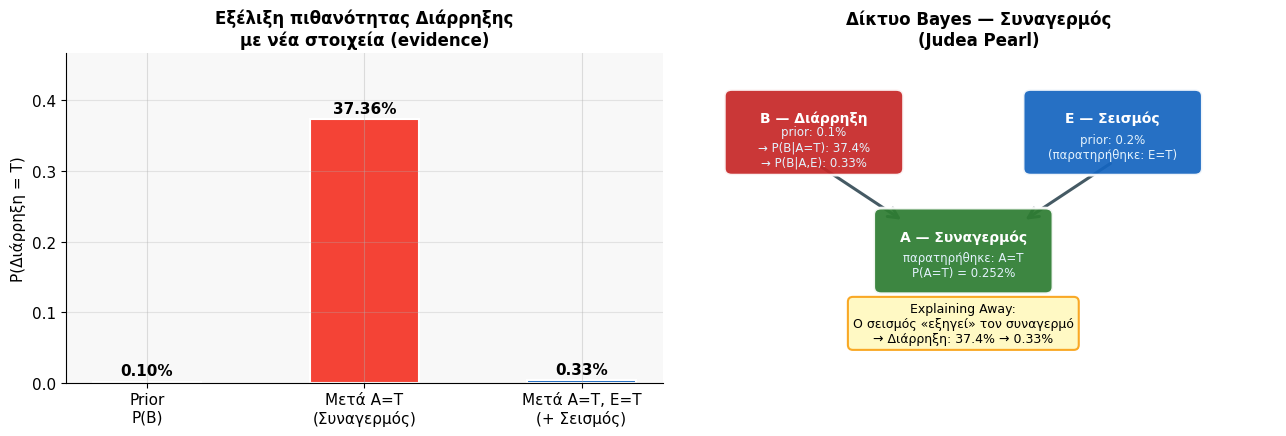

In [28]:
# ── Οπτικοποίηση: εξέλιξη πιθανότητας Διάρρηξης ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

stages = [
    ("Prior\nP(B)", P_B, "#90A4AE"),
    ("Μετά A=T\n(Συναγερμός)", P_B_given_A,  "#F44336"),
    ("Μετά A=T, E=T\n(+ Σεισμός)", P_B_given_AE, "#1565C0"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Αριστερά: ραβδόγραμμα εξέλιξης ─────────────────────────────────────
ax = axes[0]
labels = [s[0] for s in stages]
vals   = [s[1] for s in stages]
colors = [s[2] for s in stages]
bars = ax.bar(labels, vals, color=colors, edgecolor="white",
              linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val*100:.2f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylabel("P(Διάρρηξη = T)", fontsize=11)
ax.set_title("Εξέλιξη πιθανότητας Διάρρηξης\nμε νέα στοιχεία (evidence)",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.25)
ax.grid(True, axis="y", alpha=0.3)

# ── Δεξιά: δίκτυο Bayes με ενημερωμένες πιθανότητες ────────────────────
ax = axes[1]
ax.set_xlim(0, 8); ax.set_ylim(0, 5); ax.axis("off")

def node(ax, cx, cy, title, prob_lines, color, w=2.2, h=1.1):
    box = mpatches.FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor="white",
                                   linewidth=2, alpha=0.93, zorder=3)
    ax.add_patch(box)
    ax.text(cx, cy+0.22, title, ha="center", va="center",
            fontsize=10, color="white", fontweight="bold", zorder=4)
    ax.text(cx, cy-0.22, prob_lines, ha="center", va="center",
            fontsize=8.5, color="#E3F2FD", zorder=4)

node(ax, 1.8, 3.8, "B — Διάρρηξη",
     f"prior: {P_B*100:.1f}%\n→ P(B|A=T): {P_B_given_A*100:.1f}%\n→ P(B|A,E): {P_B_given_AE*100:.2f}%",
     "#C62828")
node(ax, 5.8, 3.8, "E — Σεισμός",
     f"prior: {P_E*100:.1f}%\n(παρατηρήθηκε: E=T)",
     "#1565C0")
node(ax, 3.8, 2.0, "A — Συναγερμός",
     f"παρατηρήθηκε: A=T\nP(A=T) = {P_A_true*100:.3f}%",
     "#2E7D32")

# βέλη
for x1,y1,x2,y2 in [(1.8,3.35,3.0,2.45),(5.8,3.35,4.6,2.45)]:
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color="#455A64",
                                lw=2.2, mutation_scale=18), zorder=2)

# explaining away annotation
ax.text(3.8, 0.9,
        "Explaining Away:\nΟ σεισμός «εξηγεί» τον συναγερμό\n"
        f"→ Διάρρηξη: {P_B_given_A*100:.1f}% → {P_B_given_AE*100:.2f}%",
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF9C4",
                  edgecolor="#F9A825", linewidth=1.5))

ax.set_title("Δίκτυο Bayes — Συναγερμός\n(Judea Pearl)",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()
